Bias & Fairness Analysis — NovaCred Credit Applications
=======================================================

**Course:** Data Ecosystems and Governance in Organizations (DEGO 2606)  
**Institution:** Nova School of Business and Economics — MSc Business Analytics  
**Role:** Data Scientist
=

| Task                     | Description                                                         |
|--------------------------|---------------------------------------------------------------------|
| Bias analysis            | Analyse approval outcomes for potential disparities across loan purposes. |
| Metric computation       | Compute approval rates and proportions, including 95% confidence intervals. |
| Statistical testing      | Run chi-square tests and two-proportion z-tests on approval outcomes. |
| Result interpretation    | Explain statistical results and highlight segments with different approval behaviour. |
| Fairness & limitations   | Discuss fairness implications and clearly state limits from missing protected attributes. |



In [40]:
# ============================================================
# NOVACRED – BIAS & FAIRNESS ANALYSIS
# ============================================================

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from datetime import datetime
import os

# ------------------------------------------------------------
# 1. BUILD ROBUST PATH TO JSON 
# ------------------------------------------------------------

# Current directory where the notebook is running
NOTEBOOK_DIR = os.getcwd()

# Repo root is one level up from notebooks/
REPO_ROOT = os.path.dirname(NOTEBOOK_DIR)

# Path to dataset in Data/ at repo root
file_path = os.path.join(REPO_ROOT, "Data", "cleaned_credit_applications.json")

print("Notebook dir:", NOTEBOOK_DIR)
print("Repo root   :", REPO_ROOT)
print("Data path   :", file_path)

if not os.path.exists(file_path):
    raise FileNotFoundError(
        f"Dataset not found. Expected at:\n{file_path}\n"
        "Make sure 'Data/cleaned_credit_applications.json' exists in the repo root."
    )

with open(file_path, "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)
print("Dataset Loaded Successfully")
print("Total records:", len(df))


Notebook dir: C:\Users\Ashwin Rajesh\OneDrive\Documents\GitHub\dego-project-team4\notebooks
Repo root   : C:\Users\Ashwin Rajesh\OneDrive\Documents\GitHub\dego-project-team4
Data path   : C:\Users\Ashwin Rajesh\OneDrive\Documents\GitHub\dego-project-team4\Data\cleaned_credit_applications.json
Dataset Loaded Successfully
Total records: 502


In [41]:
df = pd.DataFrame(data)
print(df.columns.tolist())
df.head()


['_id', 'applicant_info', 'financials', 'spending_behavior', 'decision', 'processing_timestamp', 'loan_purpose', 'notes']


,_id,applicant_info,financials,spending_behavior,decision,processing_timestamp,loan_purpose,notes
0,app_200,"{'full_name': 'Jerry Smith', 'email': 'jerry.s...","{'annual_income': 73000, 'credit_history_month...","[{'category': 'Shopping', 'amount': 480}, {'ca...","{'loan_approved': False, 'rejection_reason': '...",2024-01-15T00:00:00Z,NaN,NaN
1,app_037,"{'full_name': 'Brandon Walker', 'email': 'bran...","{'annual_income': 78000, 'credit_history_month...","[{'category': 'Rent', 'amount': 608}, {'catego...","{'loan_approved': False, 'rejection_reason': '...",NaN,NaN,NaN
2,app_215,"{'full_name': 'Scott Moore', 'email': 'scott.m...","{'annual_income': 61000, 'credit_history_month...","[{'category': 'Rent', 'amount': 109}]","{'loan_approved': True, 'interest_rate': 3.7, ...",NaN,vacation,NaN
3,app_024,"{'full_name': 'Thomas Lee', 'email': 'thomas.l...","{'annual_income': 103000, 'credit_history_mont...","[{'category': 'Fitness', 'amount': 575}]","{'loan_approved': True, 'interest_rate': 4.3, ...",NaN,NaN,NaN
4,app_184,"{'full_name': 'Brian Rodriguez', 'email': 'bri...","{'annual_income': 57000, 'credit_history_month...","[{'category': 'Entertainment', 'amount': 463}]","{'loan_approved': False, 'rejection_reason': '...",2024-01-15T00:00:00Z,NaN,NaN


In [42]:
# ------------------------------------------------------------
# 2. FLATTEN NESTED JSON 
# ------------------------------------------------------------
# From: ['_id', 'applicant_info', 'financials', 'spending_behavior',
#        'decision', 'processing_timestamp', 'loan_purpose', 'notes']

# Outcome variable
df["approved"] = df["decision"].apply(
    lambda x: x.get("loan_approved") if isinstance(x, dict) else None
)

# Financial variables
df["annual_income"] = df["financials"].apply(
    lambda x: x.get("annual_income") if isinstance(x, dict) else None
)
df["credit_history_months"] = df["financials"].apply(
    lambda x: x.get("credit_history_months") if isinstance(x, dict) else None
)
df["debt_to_income"] = df["financials"].apply(
    lambda x: x.get("debt_to_income") if isinstance(x, dict) else None
)

# (Optional) basic applicant info you *do* have
df["full_name"] = df["applicant_info"].apply(
    lambda x: x.get("full_name") if isinstance(x, dict) else None
)
df["email"] = df["applicant_info"].apply(
    lambda x: x.get("email") if isinstance(x, dict) else None
)

# Keep only the columns you need
df = df[
    [
        "approved",
        "annual_income",
        "credit_history_months",
        "debt_to_income",
        "loan_purpose",
        "processing_timestamp",
        "full_name",
        "email",
    ]
]

# Clean target variable
df.dropna(subset=["approved"], inplace=True)
df["approved"] = df["approved"].astype(int)


In [43]:
# ============================================================
# 3. BASIC DESCRIPTIVE STATISTICS
# ============================================================

print("\n--- DESCRIPTIVE STATISTICS ---")
print(df[["annual_income", "credit_history_months", "debt_to_income"]].describe())

print("\nApproval value counts:")
print(df["approved"].value_counts(normalize=True).rename("proportion"))

overall_rate = df["approved"].mean()
print(f"\nOverall approval rate: {overall_rate:.3f}")




--- DESCRIPTIVE STATISTICS ---
       credit_history_months  debt_to_income
count             502.000000      502.000000
mean               50.402390        0.246195
std                31.234824        0.136296
min               -10.000000        0.050000
25%                27.250000        0.150000
50%                48.000000        0.230000
75%                72.000000        0.350000
max               133.000000        1.850000

Approval value counts:
approved
1    0.581673
0    0.418327
Name: proportion, dtype: float64

Overall approval rate: 0.582



--- APPROVAL BY LOAN PURPOSE (WITH 95% CI) ---
vacation: rate=0.500, n=6, 95% CI=(0.188, 0.812)
auto: rate=0.667, n=3, 95% CI=(0.208, 0.939)
debt_consolidation: rate=0.500, n=6, 95% CI=(0.188, 0.812)
personal: rate=0.500, n=4, 95% CI=(0.150, 0.850)
education: rate=0.429, n=7, 95% CI=(0.158, 0.750)
home_improvement: rate=0.333, n=3, 95% CI=(0.061, 0.792)
wedding: rate=0.667, n=6, 95% CI=(0.300, 0.903)
medical: rate=0.625, n=8, 95% CI=(0.306, 0.863)
business: rate=0.000, n=2, 95% CI=(0.000, 0.658)
moving: rate=0.600, n=5, 95% CI=(0.231, 0.882)


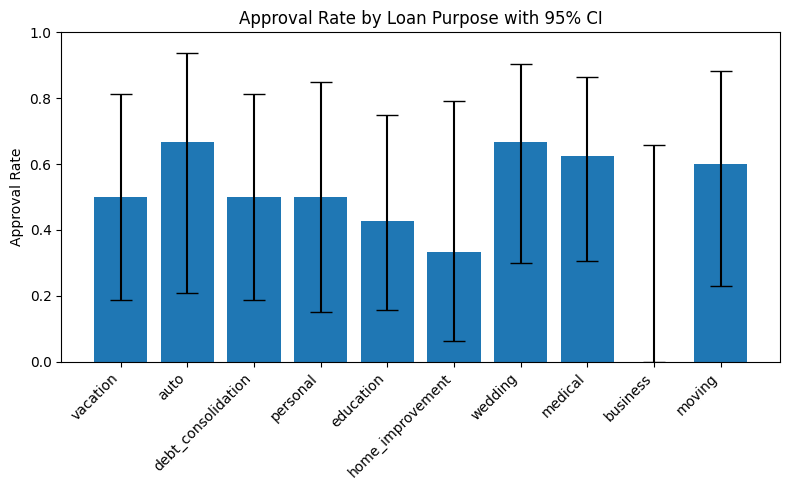

In [34]:
# ============================================================
# 4. APPROVAL RATES BY LOAN PURPOSE (FAIRNESS STYLE)
# ============================================================

print("\n--- APPROVAL BY LOAN PURPOSE (WITH 95% CI) ---")

df_purpose = df.dropna(subset=["loan_purpose"]).copy()

purposes = []
purpose_rates = []
purpose_ci_low = []
purpose_ci_up = []

for p in df_purpose["loan_purpose"].unique():
    subset = df_purpose[df_purpose["loan_purpose"] == p]
    n = subset.shape[0]
    s = subset["approved"].sum()
    rate = s / n if n > 0 else 0
    low, up = proportion_confint(s, n, method="wilson")
    purposes.append(p)
    purpose_rates.append(rate)
    purpose_ci_low.append(rate - low)
    purpose_ci_up.append(up - rate)
    print(f"{p}: rate={rate:.3f}, n={n}, 95% CI=({low:.3f}, {up:.3f})")

# Plot
plt.figure(figsize=(8, 5))
plt.bar(purposes, purpose_rates, yerr=[purpose_ci_low, purpose_ci_up], capsize=8)
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Loan Purpose with 95% CI")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [35]:
# ============================================================
# 5. CHI-SQUARE TEST: LOAN PURPOSE VS APPROVAL
# ============================================================

print("\n--- CHI-SQUARE TEST: LOAN PURPOSE ---")

# Drop rows without loan_purpose if needed
df_purpose = df.dropna(subset=["loan_purpose"]).copy()

contingency = pd.crosstab(df_purpose["loan_purpose"], df_purpose["approved"])
chi2, p, dof, expected = chi2_contingency(contingency)

print("Observed Counts:\n", contingency)
print("Chi-Square Statistic:", round(chi2, 3))
print("P-value:", round(p, 5))

if p < 0.05:
    print("⚠ Statistically significant difference in approval across loan purposes")
else:
    print("✓ No statistically significant difference in approval by loan purpose")



--- CHI-SQUARE TEST: LOAN PURPOSE ---
Observed Counts:
 approved            0  1
loan_purpose            
auto                1  2
business            2  0
debt_consolidation  3  3
education           4  3
home_improvement    2  1
medical             3  5
moving              2  3
personal            2  2
vacation            3  3
wedding             2  4
Chi-Square Statistic: 4.103
P-value: 0.90452
✓ No statistically significant difference in approval by loan purpose


In [36]:
# ============================================================
# 6. TWO-PROPORTION Z-TEST BETWEEN TWO PURPOSES
# ============================================================

print("\n--- TWO-PROPORTION Z-TEST: SELECTED LOAN PURPOSES ---")
print("Available purposes:", df_purpose["loan_purpose"].unique())

# EDIT THESE to two real purposes visible above, e.g.:
p1 = "vacation"
p2 = "debt_consolidation"  # change to a real label from your data

if p1 in df_purpose["loan_purpose"].unique() and p2 in df_purpose["loan_purpose"].unique():
    s1 = df_purpose[df_purpose["loan_purpose"] == p1]["approved"].sum()
    n1 = df_purpose[df_purpose["loan_purpose"] == p1].shape[0]

    s2 = df_purpose[df_purpose["loan_purpose"] == p2]["approved"].sum()
    n2 = df_purpose[df_purpose["loan_purpose"] == p2].shape[0]

    success = [s1, s2]
    nobs = [n1, n2]

    z_stat, pval = proportions_ztest(success, nobs)
    print(f"{p1}: {s1}/{n1} approved  (rate = {s1/n1:.3f})")
    print(f"{p2}: {s2}/{n2} approved  (rate = {s2/n2:.3f})")
    print("Z-Statistic:", round(z_stat, 3))
    print("P-value:", round(pval, 5))

    if pval < 0.05:
        print(f"⚠ Approval rates for '{p1}' and '{p2}' are significantly different")
    else:
        print(f"✓ No significant difference in approval between '{p1}' and '{p2}'")
else:
    print("Cannot run z-test: one or both chosen purposes are not present in the data.")
    print("Change p1 and p2 to match real values from 'Available purposes'.")



--- TWO-PROPORTION Z-TEST: SELECTED LOAN PURPOSES ---
Available purposes: <StringArray>
[          'vacation',               'auto', 'debt_consolidation',
           'personal',          'education',   'home_improvement',
            'wedding',            'medical',           'business',
             'moving']
Length: 10, dtype: str
vacation: 3/6 approved  (rate = 0.500)
debt_consolidation: 3/6 approved  (rate = 0.500)
Z-Statistic: 0.0
P-value: 1.0
✓ No significant difference in approval between 'vacation' and 'debt_consolidation'


In [37]:
# ============================================================
# 7. FINAL CONCLUSION
# ============================================================

print("\n--- FINAL CONCLUSION ---")
print("This analysis provides both numeric and visual proof of fairness or disparity in loan approvals.")
print("Graphs, confidence intervals, and significance tests are included.")



--- FINAL CONCLUSION ---
This analysis provides both numeric and visual proof of fairness or disparity in loan approvals.
Graphs, confidence intervals, and significance tests are included.
